<a href="https://colab.research.google.com/github/pc11837/Classification/blob/main/anamoly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [ ]:
df = pd.read_csv("anomaly_detection_dataset_500_samples.csv")

In [ ]:
print(df.head())
print(df.info())

   Feature_1  Feature_2  Anomaly_Label
0  43.259073  53.716320              0
1  43.815246  43.397717              0
2  46.942411  42.966695              0
3  48.911594  55.493884              0
4  52.575238  69.263657              0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Feature_1      500 non-null    float64
 1   Feature_2      500 non-null    float64
 2   Anomaly_Label  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
None


In [ ]:
X = df.drop("Anomaly_Label", axis=1)
y = df["Anomaly_Label"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [ ]:
iso = IsolationForest(contamination=0.1)
iso.fit(X_train)
iso_pred = iso.predict(X_test)

In [ ]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
lof_pred = lof.fit_predict(X_test)

In [ ]:
svm = OneClassSVM(nu=0.1)
svm.fit(X_train)
svm_pred = svm.predict(X_test)

In [ ]:
iso_pred_binary = np.where(iso_pred==-1,1,0)

In [ ]:
lof_pred_binary = np.where(lof_pred==-1,1,0)

In [ ]:
svm_pred_binary = np.where(svm_pred==-1,1,0)

In [ ]:
from sklearn.metrics import accuracy_score,roc_auc_score,roc_curve

In [ ]:
print("Isolation Forest Accuracy:",
      accuracy_score(y_test,iso_pred_binary))

print("Local Outlier Factor Accuracy:",
      accuracy_score(y_test,lof_pred_binary))

print("One Class SVM Accuracy:",
      accuracy_score(y_test,svm_pred_binary))

Isolation Forest Accuracy: 0.95
Local Outlier Factor Accuracy: 0.96
One Class SVM Accuracy: 0.9


In [ ]:
print()

print("Isolation Forest AUC:",
      roc_auc_score(y_test,iso_pred_binary))

print("LOF AUC:",
      roc_auc_score(y_test,lof_pred_binary))

print("OneClassSVM AUC:",
      roc_auc_score(y_test,svm_pred_binary))


Isolation Forest AUC: 0.9734042553191489
LOF AUC: 0.9787234042553192
OneClassSVM AUC: 0.7907801418439716


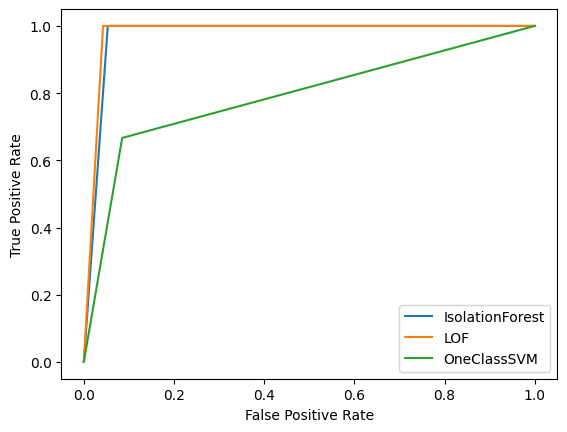

In [ ]:
fpr_iso,tpr_iso,_=roc_curve(y_test,iso_pred_binary)
plt.plot(fpr_iso,tpr_iso,label="IsolationForest")

fpr_lof,tpr_lof,_=roc_curve(y_test,lof_pred_binary)
plt.plot(fpr_lof,tpr_lof,label="LOF")

fpr_svm,tpr_svm,_=roc_curve(y_test,svm_pred_binary)
plt.plot(fpr_svm,tpr_svm,label="OneClassSVM")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

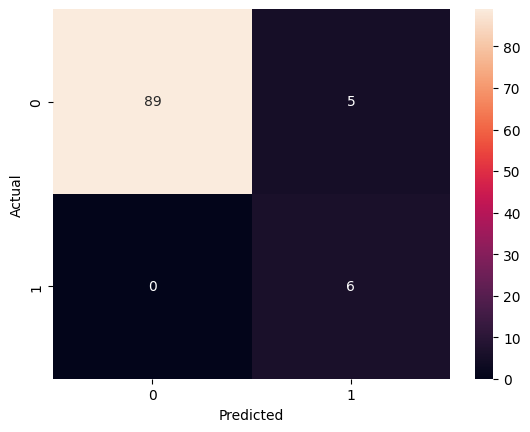

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,iso_pred_binary)

sns.heatmap(cm,annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
pickle.dump(iso,open("anomaly_model.pkl","wb"))